# Unlearning Definitions-Only Benchmark — Local Context Test Set

This notebook is a corrected, minimally modified version of the working definitions-only pipeline.

It uses one input workbook only:

- `GPT Test`: the attached **Local Context Test Set** exactly as supplied (42 rows)
- `Codebook`: the current updated codebook exactly as supplied

The model receives the target paragraph, the verified local context already stored in the test set, and the definitions-only codebook. Human labels, codes, agencies, and rationales are never included in the prompt.

Each provider runs independently. API calls are off by default; turn on only the provider you intend to run.

In [ ]:
# Run once in a fresh Colab/runtime if packages are missing.
%pip install -q -U openpyxl xlsxwriter tqdm python-dotenv tiktoken openai anthropic google-genai pydantic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.6/676.6 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 998.3/998.3 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.8 MB/s eta 0:00:00


## 1. Imports and configuration

In [ ]:
from pathlib import Path
from datetime import datetime, timezone
from collections import defaultdict
from getpass import getpass
from typing import Literal

import os
import re
import json
import time
import math
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pydantic import BaseModel, ConfigDict, Field, ValidationError
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef,
)
from tqdm.auto import tqdm
from dotenv import load_dotenv


def resolve_input_path(filename: str) -> Path:
    """Find an uploaded input in Colab, /mnt/data, or the current folder."""
    candidates = [
        Path('/content') / filename,
        Path('/mnt/data') / filename,
        Path(filename),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


WORKBOOK_FILENAME = 'Unlearning_Codebook_Local_Context_Test_Set.xlsx'
WORKBOOK_PATH = resolve_input_path(WORKBOOK_FILENAME)
TEST_SHEET = 'GPT Test'
CODEBOOK_SHEET = 'Codebook'
EXPECTED_TEST_ROWS = 42
EXPECTED_LABEL_COUNTS = {'Yes': 32, 'No': 10}

PROMPT_VERSION = 'v6_fixed_definitions_only_local_context_42'
PROMPT_VARIANTS_TO_RUN = ['definitions_only_local_context']

OUTPUT_DIR = Path('outputs_unlearning_local_context_fixed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Turn on only the provider(s) you want to call.
RUN_OPENAI_CALLS = True
RUN_ANTHROPIC_CALLS = True
RUN_GEMINI_CALLS = True

# When a selected provider key is missing, ask for it securely.
PROMPT_FOR_MISSING_KEYS = True

STOP_PROVIDER_ON_FIRST_ERROR = True
RESUME_FROM_JSONL = True
ROW_LIMIT = None
MAX_TEXT_CHARS = None
MAX_CONTEXT_CHARS = None
MAX_OUTPUT_TOKENS = 2500
REQUEST_SLEEP_SECONDS = 0.2
MAX_ESTIMATED_COST_USD_PER_PROVIDER = 5.00

MODEL_CONFIG = [
    {
        'provider': 'openai',
        'model': 'gpt-5.6-terra',
        'enabled': True,
        'api_key_env': 'OPENAI_API_KEY',
        'input_usd_per_1m': 0.20,
        'output_usd_per_1m': 1.25,
        'reasoning_effort': 'low',
        'request_sleep_seconds': 0.2,
    },
    {
        'provider': 'anthropic',
        'model': 'claude-sonnet-5',
        'enabled': True,
        'api_key_env': 'ANTHROPIC_API_KEY',
        'input_usd_per_1m': 2.00,
        'output_usd_per_1m': 10.00,
        'effort': 'low',
        'request_sleep_seconds': 0.2,
    },
    {
        'provider': 'gemini',
        'model': 'gemini-3.1-flash-lite',
        'enabled': True,
        'api_key_env': 'GEMINI_API_KEY',
        'input_usd_per_1m': 0.75,
        'output_usd_per_1m': 4.50,
        'thinking_level': 'minimal',
        'request_sleep_seconds': 0.5,
    },
]

RUN_SWITCH_BY_PROVIDER = {
    'openai': RUN_OPENAI_CALLS,
    'anthropic': RUN_ANTHROPIC_CALLS,
    'gemini': RUN_GEMINI_CALLS,
}

print('Workbook:', WORKBOOK_PATH)
print('Prompt version:', PROMPT_VERSION)
print('Output folder:', OUTPUT_DIR.resolve())
print('Run switches:', RUN_SWITCH_BY_PROVIDER)

Workbook: /content/Unlearning_Codebook_Local_Context_Test_Set.xlsx
Prompt version: v6_fixed_definitions_only_local_context_42
Output folder: /content/outputs_unlearning_local_context_fixed
Run switches: {'openai': True, 'anthropic': True, 'gemini': True}


## 2. Load API keys into environment variables

In [ ]:
# 1) Load keys from a local .env file when present.
load_dotenv(dotenv_path=Path('.env'))

# 2) Load keys from Google Colab Secrets when available.
try:
    from google.colab import userdata

    for env_name in ['OPENAI_API_KEY', 'ANTHROPIC_API_KEY', 'GEMINI_API_KEY']:
        if not os.getenv(env_name):
            try:
                value = userdata.get(env_name)
            except Exception:
                value = None
            if value:
                os.environ[env_name] = value
except ImportError:
    pass

# 3) Securely prompt only for providers whose run switch is True.
required_key_names = []
for cfg in MODEL_CONFIG:
    provider = cfg['provider']
    if cfg.get('enabled', True) and RUN_SWITCH_BY_PROVIDER.get(provider, False):
        required_key_names.append(cfg['api_key_env'])

for env_name in required_key_names:
    if not os.getenv(env_name) and PROMPT_FOR_MISSING_KEYS:
        entered = getpass(f'Enter {env_name} (input hidden): ').strip()
        if entered:
            os.environ[env_name] = entered

missing_keys = [name for name in required_key_names if not os.getenv(name)]
if missing_keys:
    raise EnvironmentError(
        'Missing required API key environment variable(s): ' + ', '.join(missing_keys)
    )

if required_key_names:
    print('API-key environment variables ready:', ', '.join(required_key_names))
else:
    print('No provider run switch is enabled, so no API key is required yet.')

# Direct environment-variable assignment is also supported when needed:
# os.environ['ANTHROPIC_API_KEY'] = 'your-key-here'
# os.environ['OPENAI_API_KEY'] = 'your-key-here'
# os.environ['GEMINI_API_KEY'] = 'your-key-here'

API-key environment variables ready: OPENAI_API_KEY, ANTHROPIC_API_KEY, GEMINI_API_KEY


## 3. Load and validate the attached 42-row test set and current codebook

In [ ]:
def drop_empty_unnamed_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.dropna(axis=1, how='all')
    return df.loc[:, ~df.columns.astype(str).str.match(r'^Unnamed', na=False)]


if not WORKBOOK_PATH.exists():
    raise FileNotFoundError(
        f'Workbook not found: {WORKBOOK_PATH}. Upload {WORKBOOK_FILENAME} or update WORKBOOK_PATH.'
    )

excel_file = pd.ExcelFile(WORKBOOK_PATH, engine='openpyxl')
if excel_file.sheet_names != [TEST_SHEET, CODEBOOK_SHEET]:
    raise ValueError(
        f'Expected exactly [{TEST_SHEET!r}, {CODEBOOK_SHEET!r}], found {excel_file.sheet_names}.'
    )

test_df = drop_empty_unnamed_columns(
    pd.read_excel(WORKBOOK_PATH, sheet_name=TEST_SHEET, engine='openpyxl')
)
raw_codebook_df = pd.read_excel(
    WORKBOOK_PATH,
    sheet_name=CODEBOOK_SHEET,
    header=None,
    engine='openpyxl',
)

required_test_cols = {
    'Number',
    'Text Content',
    'Document',
    'Local Context (±2 source paragraphs)',
    'Unlearning',
}
missing_test_cols = required_test_cols - set(test_df.columns)
if missing_test_cols:
    raise ValueError(
        f'{TEST_SHEET!r} is missing required columns: {sorted(missing_test_cols)}'
    )

for optional_col in [
    'PDF Page', 'Section Heading', 'Paragraph Order', 'Codes',
    'Target', 'Government Agency', 'Rationale',
]:
    if optional_col not in test_df.columns:
        test_df[optional_col] = ''

header_candidates = raw_codebook_df.index[
    raw_codebook_df.iloc[:, 0].astype(str).str.strip().str.lower().eq('code')
].tolist()
if not header_candidates:
    raise ValueError(
        f'Could not find the Codebook table header row in {CODEBOOK_SHEET!r}.'
    )

codebook_header_row = header_candidates[0]
codebook_df = raw_codebook_df.iloc[codebook_header_row + 1:].copy()
codebook_df.columns = [
    str(value).strip() if not pd.isna(value) else ''
    for value in raw_codebook_df.iloc[codebook_header_row].tolist()
]
codebook_df = codebook_df.dropna(axis=0, how='all')
codebook_df = codebook_df.loc[:, [column for column in codebook_df.columns if column]]
codebook_df = codebook_df.reset_index(drop=True)

required_codebook_cols = {
    'Code', 'Definition', 'Detection Logic', 'Examples',
    'Positive Clarification', 'Negative Clarification',
}
missing_codebook_cols = required_codebook_cols - set(codebook_df.columns)
if missing_codebook_cols:
    raise ValueError(
        'Current Codebook is missing required columns: ' + ', '.join(sorted(missing_codebook_cols))
    )

print('Raw GPT Test shape:', test_df.shape)
print('Codebook shape:', codebook_df.shape)
display(test_df.head(3))
display(codebook_df.head(8))

Raw GPT Test shape: (42, 12)
Codebook shape: (14, 6)


,Number,Text Content,Document,PDF Page,Section Heading,Paragraph Order,Local Context (±2 source paragraphs),Codes,Unlearning,Target,Government Agency,Rationale
0,P001,"• Coordination within EPA, with State and loca...",Lessons Learned: EPA’s Response to Hurricane K...,3,What We Found,7,[PREVIOUS 1]\nIn our prior reports on EPA’s re...,Unlearning: No,No,NaN,NaN,Not unlearning. As no logic being abandoned.
1,P002,"EPA officials told us that, in some instances,...",Lessons Learned: EPA’s Response to Hurricane K...,9–10,Coordination within EPA and with Others → Drin...,46–49,[PREVIOUS 2]\nThe following sections discuss i...,Unlearning: No,No,NaN,NaN,Not unlearning. As no logic being abandoned ju...
2,P003,"From our review of wastewater issues, we found...",Lessons Learned: EPA’s Response to Hurricane K...,11,Wastewater Response,55,[PREVIOUS 2]\n. . . develop integrated operati...,Unlearning: Yes | Government Agency: EPA,Yes,NaN,EPA,Unlearning as it states EPA was not commuunica...


,Code,Definition,Detection Logic,Examples,Positive Clarification,Negative Clarification
0,Step 1 -- Binary classification based on unlea...,NaN,NaN,NaN,NaN,NaN
1,Unlearning (Yes/No),Unlearning is the deliberate process by which ...,Does the text explicitly identify a prior poli...,"""[T]he Federal government should not rely on t...",Code when the text:\n• Names a specific prior ...,DO NOT code if:\n• The text only documents wha...
2,STEP 2 — TARGET OF UNLEARNING (assign one per ...,NaN,NaN,NaN,NaN,NaN
3,Target (Leadership),"The text questions or redefines the role, auth...",Does the text call for redefining or redistrib...,"""[A] single individual directly responsible an...",Code when the text:\n • Calls into question wh...,DO NOT code if:\n • The text recommends appoin...
4,"Target (laws, plans and policies)","The text calls for terminating, replacing, or ...","Does the text identify a specific law, plan, o...","""Removing statutory restrictions on DOD author...",Code when the text:\n • Calls for eliminating ...,DO NOT code if:\n • The text proposes reform o...
5,Target (capabilities),The text identifies a technical system — model...,Does the text identify a specific technical sy...,"""We identified the need for the federal govern...",Code when the text:\n • Identifies a technical...,DO NOT code if:\n • The text describes routine...
6,Target (funds and resource allocation),The text calls for changing how disaster funds...,Does the text identify the existing funds mana...,"""Federal agencies involved in managing interna...",Code when the text:\n • Calls for changing the...,DO NOT code if:\n • The text only requests add...
7,"Target (misclleanous) organizational culture, ...",The text calls for unlearning in a domain not ...,Does the text call for discarding a prior assu...,Use sparingly. Flag for team discussion if use...,Code when the text:\n • Explicitly rejects a p...,DO NOT use as a default catch-all. If the pass...


## 4. Clean labels without changing the supplied test rows

In [ ]:
def normalize_yes_no(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if text in {'yes', 'y', 'true', '1', 'unlearning'} or text.startswith('yes'):
        return 'Yes'
    if text in {'no', 'n', 'false', '0', 'not unlearning', 'non-unlearning'} or text.startswith('no'):
        return 'No'
    return np.nan


def clean_single_paragraph(value, max_chars=None):
    if pd.isna(value):
        return ''
    text = re.sub(r'\s+', ' ', str(value)).strip()
    if max_chars is not None and len(text) > max_chars:
        text = text[:max_chars].rstrip() + ' ... [TRUNCATED]'
    return text


def clean_context(value, max_chars=None):
    if pd.isna(value):
        return ''
    cleaned_lines = []
    for line in str(value).splitlines():
        cleaned = re.sub(r'[ \t]+', ' ', line).strip()
        if cleaned:
            cleaned_lines.append(cleaned)
    text = '\n'.join(cleaned_lines)
    if max_chars is not None and len(text) > max_chars:
        text = text[:max_chars].rstrip() + '\n... [TRUNCATED]'
    return text


test_df['ground_truth_unlearning'] = test_df['Unlearning'].apply(normalize_yes_no)
test_df['ground_truth_target'] = test_df['Target'].fillna('').astype(str).str.strip()
test_df['ground_truth_agency'] = test_df['Government Agency'].fillna('').astype(str).str.strip()

invalid_rows = test_df[
    test_df['Text Content'].isna() | test_df['ground_truth_unlearning'].isna()
].copy()
if not invalid_rows.empty:
    raise ValueError(
        'The supplied GPT Test contains missing text or invalid Unlearning labels:\n'
        + invalid_rows[['Number', 'Unlearning']].to_string(index=False)
    )

if len(test_df) != EXPECTED_TEST_ROWS:
    raise AssertionError(
        f'Expected exactly {EXPECTED_TEST_ROWS} rows from the attached Local Context Test Set; found {len(test_df)}.'
    )

actual_counts = test_df['ground_truth_unlearning'].value_counts().to_dict()
if actual_counts != EXPECTED_LABEL_COUNTS:
    raise AssertionError(
        f'Expected label counts {EXPECTED_LABEL_COUNTS}; found {actual_counts}.'
    )

if test_df['Number'].astype(str).duplicated().any():
    duplicates = test_df.loc[test_df['Number'].astype(str).duplicated(keep=False), 'Number'].tolist()
    raise AssertionError(f'Duplicate paragraph IDs found: {duplicates}')

if ROW_LIMIT is not None:
    test_df = test_df.head(ROW_LIMIT).copy()

print(f'Validated {len(test_df)} test rows.')
print('Label distribution:', actual_counts)
print('Rows with local context:', int(test_df['Local Context (±2 source paragraphs)'].notna().sum()))
print('No human Codes, labels, agencies, or rationales will be placed in model prompts.')

Validated 42 test rows.
Label distribution: {'Yes': 32, 'No': 10}
Rows with local context: 42
No human Codes, labels, agencies, or rationales will be placed in model prompts.


## 5. Serialize the current definitions-only codebook

In [ ]:
def prompt_value(value) -> str:
    if pd.isna(value):
        return ''
    return clean_single_paragraph(value, max_chars=None)


def make_codebook_text(codebook: pd.DataFrame) -> str:
    parts = []
    for _, row in codebook.iterrows():
        code_name = prompt_value(row.get('Code', ''))
        if not code_name or code_name.lower() == 'nan':
            continue
        parts.append('\n'.join([
            f'Code: {code_name}',
            f'Definition: {prompt_value(row.get("Definition", ""))}',
            f'Detection logic: {prompt_value(row.get("Detection Logic", ""))}',
            f'Examples: {prompt_value(row.get("Examples", ""))}',
            f'Positive: {prompt_value(row.get("Positive Clarification", ""))}',
            f'Negative: {prompt_value(row.get("Negative Clarification", ""))}',
        ]))
    return '\n\n'.join(parts)


CODEBOOK_TEXT = make_codebook_text(codebook_df)
assert 'Unlearning (Yes/No)' in CODEBOOK_TEXT
assert 'Examples:' in CODEBOOK_TEXT
print('Serialized codebook rows:', CODEBOOK_TEXT.count('Code: '))
print('Codebook characters:', len(CODEBOOK_TEXT))

Serialized codebook rows: 14
Codebook characters: 10701


## 6. Single-stage evidence-first prompt using the supplied local context

In [ ]:
BASE_SYSTEM_PROMPT = 'Return valid JSON only. Do not include markdown.'

COMMON_TASK_BLOCK = """You are coding federal disaster-policy text using the supplied unlearning codebook.

The TARGET PARAGRAPH is the unit of analysis. Use LOCAL CONTEXT only to resolve references, connect ideas, or understand what the target paragraph is discussing. Do not label the target paragraph as unlearning solely because a neighboring paragraph contains unlearning.

Decision procedure:
1. Identify the prior policy, assumption, practice, routine, governance arrangement, or technical system at issue in the target paragraph.
2. Identify how it is presented as inadequate, harmful, obsolete, or connected to failure.
3. Identify the proposed departure from that prior approach.
4. Distinguish replacement or fundamental rethinking from ordinary improvement, added capacity, better implementation, or diagnosis alone.
5. Decide whether unlearning is present.
6. If unlearning is present, assign one target type and identify the agency or sub-unit stated in the text.

The paragraph does not need to use the literal words 'abandon' or 'replace'. Phrases such as 'move away from', 'no longer rely on', 'shift authority', or an explicit old-approach-versus-new-approach contrast may qualify. However, the target paragraph must still show a substantive departure from an identifiable prior approach.

Evidence fields must be grounded in the TARGET PARAGRAPH. Local context may clarify meaning, but it must not supply the decisive evidence when that evidence is absent from the target paragraph.""".strip()

JSON_SCHEMA_NOTE = """Return valid JSON only with this structure:
{
  "prior_practice_evidence": "short quotation or faithful phrase from the target paragraph, otherwise null",
  "failure_evidence": "short quotation or faithful phrase from the target paragraph, otherwise null",
  "proposed_change_evidence": "short quotation or faithful phrase from the target paragraph, otherwise null",
  "change_type": "replace_or_fundamentally_rethink | improve_or_add | diagnosis_only | unclear",
  "unlearning_present": true/false,
  "target_type": "Leadership | laws_plans_policies | capabilities | funds_resources | misc_organizational | none",
  "agency": "agency or sub-unit name if stated, otherwise null",
  "confidence": 0.0 to 1.0,
  "rationale": "one or two concise sentences"
}

Consistency requirements:
- If unlearning_present is false, target_type must be "none".
- If unlearning_present is true, change_type should normally be "replace_or_fundamentally_rethink" and all three evidence fields should be non-null.
- Do not infer an agency that is not named or clearly referenced in the target paragraph or local context.""".strip()


class AnnotationOutput(BaseModel):
    model_config = ConfigDict(extra='forbid')

    prior_practice_evidence: str | None
    failure_evidence: str | None
    proposed_change_evidence: str | None
    change_type: Literal[
        'replace_or_fundamentally_rethink',
        'improve_or_add',
        'diagnosis_only',
        'unclear',
    ]
    unlearning_present: bool
    target_type: Literal[
        'Leadership',
        'laws_plans_policies',
        'capabilities',
        'funds_resources',
        'misc_organizational',
        'none',
    ]
    agency: str | None
    confidence: float = Field(ge=0.0, le=1.0)
    rationale: str


ANNOTATION_JSON_SCHEMA = AnnotationOutput.model_json_schema()


def build_user_prompt(variant_name: str, test_row: pd.Series) -> str:
    if variant_name != 'definitions_only_local_context':
        raise ValueError(f'Unsupported prompt variant: {variant_name!r}')

    target_text = clean_single_paragraph(
        test_row['Text Content'], max_chars=MAX_TEXT_CHARS
    )
    local_context = clean_context(
        test_row['Local Context (±2 source paragraphs)'], max_chars=MAX_CONTEXT_CHARS
    ) or '[No local context supplied]'
    paragraph_id = test_row.get('Number', test_row.name)

    return f"""{COMMON_TASK_BLOCK}

Codebook:
{CODEBOOK_TEXT}

{JSON_SCHEMA_NOTE}

Paragraph ID: {paragraph_id}

TARGET PARAGRAPH:
{target_text}

LOCAL CONTEXT (±2 source paragraphs):
{local_context}""".strip()


def build_prompt_messages(variant_name: str, test_row: pd.Series) -> list[dict]:
    return [
        {'role': 'system', 'content': BASE_SYSTEM_PROMPT},
        {'role': 'user', 'content': build_user_prompt(variant_name, test_row)},
    ]


def prompt_sha256(messages: list[dict]) -> str:
    canonical = json.dumps(
        messages, ensure_ascii=False, sort_keys=True, separators=(',', ':')
    )
    return hashlib.sha256(canonical.encode('utf-8')).hexdigest()


preview_messages = build_prompt_messages(PROMPT_VARIANTS_TO_RUN[0], test_df.iloc[0])
preview_prompt = preview_messages[1]['content']
assert 'TARGET PARAGRAPH:' in preview_prompt
assert 'LOCAL CONTEXT (±2 source paragraphs):' in preview_prompt
assert 'ground_truth_unlearning' not in preview_prompt

prompt_audit_df = pd.DataFrame([{
    'prompt_version': PROMPT_VERSION,
    'prompt_variant': PROMPT_VARIANTS_TO_RUN[0],
    'prompt_sha256_first_row': prompt_sha256(preview_messages),
    'characters_first_row': len(preview_prompt),
    'contains_codebook': 'Codebook:' in preview_prompt,
    'contains_target_paragraph': 'TARGET PARAGRAPH:' in preview_prompt,
    'contains_local_context': 'LOCAL CONTEXT (±2 source paragraphs):' in preview_prompt,
    'contains_evidence_schema': 'prior_practice_evidence' in preview_prompt,
}])

print('Prompt checks passed.')
display(prompt_audit_df)
print(preview_prompt[:7000])

Prompt checks passed.


,prompt_version,prompt_variant,prompt_sha256_first_row,characters_first_row,contains_codebook,contains_target_paragraph,contains_local_context,contains_evidence_schema
0,v6_fixed_definitions_only_local_context_42,definitions_only_local_context,9f7774b0d65563f264be8a5101ea6d92384b37773cb8a4...,15520,True,True,True,True


You are coding federal disaster-policy text using the supplied unlearning codebook.

The TARGET PARAGRAPH is the unit of analysis. Use LOCAL CONTEXT only to resolve references, connect ideas, or understand what the target paragraph is discussing. Do not label the target paragraph as unlearning solely because a neighboring paragraph contains unlearning.

Decision procedure:
1. Identify the prior policy, assumption, practice, routine, governance arrangement, or technical system at issue in the target paragraph.
2. Identify how it is presented as inadequate, harmful, obsolete, or connected to failure.
3. Identify the proposed departure from that prior approach.
4. Distinguish replacement or fundamental rethinking from ordinary improvement, added capacity, better implementation, or diagnosis alone.
5. Decide whether unlearning is present.
6. If unlearning is present, assign one target type and identify the agency or sub-unit stated in the text.

The paragraph does not need to use the liter

## 7. Token and cost preflight

In [ ]:
def estimate_tokens_text(text: str, provider: str = 'generic') -> int:
    if text is None:
        return 0
    text = str(text)
    if provider == 'openai':
        try:
            import tiktoken
            return len(tiktoken.get_encoding('cl100k_base').encode(text))
        except Exception:
            pass
    return max(1, math.ceil(len(text) / 4))


def estimate_messages_tokens(messages: list[dict], provider: str = 'generic') -> int:
    return sum(
        estimate_tokens_text(message.get('content', ''), provider) + 6
        for message in messages
    ) + 10


def cost_from_tokens(input_tokens: int, output_tokens: int, cfg: dict) -> float:
    return (
        input_tokens / 1_000_000 * cfg['input_usd_per_1m']
        + output_tokens / 1_000_000 * cfg['output_usd_per_1m']
    )


def model_effort_descriptor(cfg: dict) -> str:
    if cfg['provider'] == 'openai':
        return f"reasoning_effort={cfg.get('reasoning_effort', 'none')}"
    if cfg['provider'] == 'anthropic':
        return f"effort={cfg['effort']}" if cfg.get('effort') is not None else 'effort=omitted'
    if cfg['provider'] == 'gemini':
        return f"thinking_level={cfg.get('thinking_level', 'low')}"
    return 'default'


def active_model_configs() -> list[dict]:
    return [cfg for cfg in MODEL_CONFIG if cfg.get('enabled', True)]


def estimate_full_grid(
    test_rows: pd.DataFrame,
    model_configs: list[dict],
    variants: list[str],
    assumed_output_tokens: int = 220,
) -> pd.DataFrame:
    rows = []
    for cfg in model_configs:
        for variant in variants:
            input_total = sum(
                estimate_messages_tokens(
                    build_prompt_messages(variant, row), cfg['provider']
                )
                for _, row in test_rows.iterrows()
            )
            output_total = assumed_output_tokens * len(test_rows)
            rows.append({
                'provider': cfg['provider'],
                'model': cfg['model'],
                'model_effort': model_effort_descriptor(cfg),
                'prompt_version': PROMPT_VERSION,
                'prompt_variant': variant,
                'n_rows': len(test_rows),
                'estimated_input_tokens': int(input_total),
                'assumed_output_tokens': int(output_total),
                'estimated_total_tokens': int(input_total + output_total),
                'estimated_cost_usd': cost_from_tokens(input_total, output_total, cfg),
            })
    return pd.DataFrame(rows)


estimate_df = estimate_full_grid(
    test_df,
    active_model_configs(),
    PROMPT_VARIANTS_TO_RUN,
)
display(estimate_df)

,provider,model,model_effort,prompt_version,prompt_variant,n_rows,estimated_input_tokens,assumed_output_tokens,estimated_total_tokens,estimated_cost_usd
0,openai,gpt-5.6-terra,reasoning_effort=low,v6_fixed_definitions_only_local_context_42,definitions_only_local_context,42,140649,9240,149889,0.039680
1,anthropic,claude-sonnet-5,effort=low,v6_fixed_definitions_only_local_context_42,definitions_only_local_context,42,182361,9240,191601,0.457122
2,gemini,gemini-3.1-flash-lite,thinking_level=minimal,v6_fixed_definitions_only_local_context_42,definitions_only_local_context,42,182361,9240,191601,0.178351


## 8. Provider API wrappers retained from the working pipeline

In [ ]:
def extract_json_object(text: str) -> dict:
    """Parse a JSON object from a response, with a conservative fallback."""
    if isinstance(text, dict):
        return text
    s = str(text or "").strip()
    if not s:
        return {}

    try:
        parsed = json.loads(s)
        return parsed if isinstance(parsed, dict) else {}
    except json.JSONDecodeError:
        pass

    match = re.search(r"\{.*\}", s, flags=re.DOTALL)
    if not match:
        return {}

    try:
        parsed = json.loads(match.group(0))
        return parsed if isinstance(parsed, dict) else {}
    except json.JSONDecodeError:
        return {}


def normalize_model_prediction(parsed: dict, raw_text: str = ""):
    """Normalize the common structured output or conservative legacy fallbacks to Yes/No."""
    if isinstance(parsed, dict):
        if "unlearning_present" in parsed:
            return normalize_yes_no(parsed.get("unlearning_present"))

        for key in ["unlearning", "prediction", "label", "answer", "classification"]:
            if key in parsed:
                normalized = normalize_yes_no(parsed.get(key))
                if not pd.isna(normalized):
                    return normalized

    s = str(raw_text or "").strip()
    field_match = re.search(
        r'"?(?:unlearning_present|unlearning|label|prediction|answer|classification)"?\s*:\s*"?(yes|no|true|false)"?',
        s,
        flags=re.IGNORECASE,
    )
    if field_match:
        return normalize_yes_no(field_match.group(1))

    if len(s) < 200:
        yn_match = re.search(r"\b(yes|no)\b", s, flags=re.IGNORECASE)
        if yn_match:
            return normalize_yes_no(yn_match.group(1))

    return np.nan


def normalize_confidence(value):
    """Return a float in [0, 1], otherwise NaN."""
    try:
        number = float(value)
    except (TypeError, ValueError):
        return np.nan
    return number if 0.0 <= number <= 1.0 else np.nan


class APIErrorForRetry(Exception):
    pass


class NonRetryableQuotaError(RuntimeError):
    pass


class NonRetryableRequestError(RuntimeError):
    pass


def _retry_wait_from_error(error: Exception, default_wait: float) -> float:
    """Honor provider retry-delay hints such as retryDelay:'36s' or 'Please retry in 36.87s'."""
    text = str(error)
    patterns = [
        r"retryDelay[^0-9]*(\d+(?:\.\d+)?)s",
        r"Please retry in\s+(\d+(?:\.\d+)?)s",
        r"retry in\s+(\d+(?:\.\d+)?)\s*seconds?",
    ]
    for pattern in patterns:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            return float(match.group(1)) + 1.0
    return default_wait


def _is_nonretryable_request_error(error: Exception) -> bool:
    """Do not waste retries on malformed payloads, deprecated parameters, or schema errors."""
    text = str(error).lower()
    request_markers = [
        "error code: 400",
        "400 invalid_argument",
        "invalid_request_error",
        "invalid json payload",
        "unknown name",
        "deprecated for this model",
        "cannot find field",
    ]
    return any(marker in text for marker in request_markers)


def retry_api_call(max_attempts=4, min_wait=5, max_wait=90):
    def decorator(fn):
        def wrapper(*args, **kwargs):
            last_error = None

            for attempt in range(max_attempts):
                try:
                    return fn(*args, **kwargs)

                except (
                    NonRetryableQuotaError,
                    NonRetryableRequestError,
                ):
                    raise

                except Exception as e:
                    last_error = e

                    # Malformed requests/configuration errors
                    # cannot be fixed by waiting.
                    if _is_nonretryable_request_error(e):
                        raise NonRetryableRequestError(
                            "Non-retryable API "
                            "request/configuration error in "
                            f"{fn.__name__}: {e}"
                        ) from e

                    # On paid Gemini, quota/rate-limit 429s are
                    # treated as transient and retried using the
                    # provider's retry-delay hint.
                    if attempt == max_attempts - 1:
                        raise

                    default_wait = min(
                        max_wait,
                        min_wait * (2 ** attempt),
                    )

                    wait_seconds = min(
                        max_wait,
                        _retry_wait_from_error(
                            e,
                            default_wait,
                        ),
                    )

                    print(
                        "Retrying after transient error from "
                        f"{fn.__name__}: {e}\n"
                        f"Waiting {wait_seconds:.1f}s..."
                    )

                    time.sleep(wait_seconds)

            raise last_error

        return wrapper

    return decorator


def _common_api_result(
    *,
    raw_response: str,
    input_tokens: int,
    output_tokens: int,
    total_tokens: int,
    latency_seconds: float,
    reasoning_tokens: int = 0,
) -> dict:
    return {
        "raw_response": str(raw_response or ""),
        "input_tokens": int(input_tokens or 0),
        "output_tokens": int(output_tokens or 0),
        "total_tokens": int(total_tokens or (input_tokens or 0) + (output_tokens or 0)),
        "latency_seconds": float(latency_seconds),
        "reasoning_tokens": int(reasoning_tokens or 0),
    }


@retry_api_call(max_attempts=3, min_wait=5, max_wait=45)
def call_openai(messages: list[dict], cfg: dict) -> dict:
    """OpenAI Responses API + Pydantic Structured Outputs + explicit reasoning effort."""
    from openai import OpenAI

    client = OpenAI(api_key=os.getenv(cfg["api_key_env"]))
    system_text = next((m["content"] for m in messages if m["role"] == "system"), "")
    response_input = [m for m in messages if m["role"] != "system"]

    start = time.time()
    response = client.responses.parse(
        model=cfg["model"],
        instructions=system_text,
        input=response_input,
        reasoning={"effort": cfg.get("reasoning_effort", "low")},
        max_output_tokens=MAX_OUTPUT_TOKENS,
        text_format=AnnotationOutput,
        store=False,
    )
    latency = time.time() - start

    parsed_obj = response.output_parsed
    if parsed_obj is None:
        raise APIErrorForRetry(
            f"OpenAI returned no parsed structured output. Raw output: {response.output_text!r}"
        )

    raw_text = json.dumps(parsed_obj.model_dump(), ensure_ascii=False)

    usage = getattr(response, "usage", None)
    input_tokens = getattr(usage, "input_tokens", 0) or 0
    output_tokens = getattr(usage, "output_tokens", 0) or 0
    total_tokens = getattr(usage, "total_tokens", 0) or input_tokens + output_tokens

    output_details = getattr(usage, "output_tokens_details", None)
    reasoning_tokens = getattr(output_details, "reasoning_tokens", 0) or 0

    return _common_api_result(
        raw_response=raw_text,
        input_tokens=input_tokens,
        output_tokens=output_tokens,
        total_tokens=total_tokens,
        latency_seconds=latency,
        reasoning_tokens=reasoning_tokens,
    )


@retry_api_call(max_attempts=3, min_wait=5, max_wait=45)
def call_anthropic(messages: list[dict], cfg: dict) -> dict:
    """Anthropic messages.parse() + Pydantic Structured Outputs; effort is sent only when configured."""
    from anthropic import Anthropic

    client = Anthropic(api_key=os.environ[cfg["api_key_env"]])

    system_text = "\n".join(
        m.get("content", "")
        for m in messages
        if m.get("role") == "system"
    ).strip()

    anthropic_messages = [
        {"role": m["role"], "content": m.get("content", "")}
        for m in messages
        if m.get("role") in {"user", "assistant"}
    ]


    start = time.time()

    anthropic_request = {
        "model": cfg["model"],
        "max_tokens": MAX_OUTPUT_TOKENS,
        "system": system_text,
        "messages": anthropic_messages,
        "output_format": AnnotationOutput,
    }

    # Sonnet 5 supports effort.
    # Haiku 4.5 does not.
    if cfg.get("effort") is not None:
        anthropic_request["output_config"] = {
            "effort": cfg["effort"]
        }

    response = client.messages.parse(
        **anthropic_request
    )

    latency = time.time() - start


    parsed_obj = response.parsed_output
    if parsed_obj is None:
        raise APIErrorForRetry("Anthropic returned no parsed structured output.")

    raw_text = json.dumps(parsed_obj.model_dump(), ensure_ascii=False)

    usage = getattr(response, "usage", None)
    input_tokens = getattr(usage, "input_tokens", 0) or 0
    output_tokens = getattr(usage, "output_tokens", 0) or 0

    return _common_api_result(
        raw_response=raw_text,
        input_tokens=input_tokens,
        output_tokens=output_tokens,
        total_tokens=input_tokens + output_tokens,
        latency_seconds=latency,
        reasoning_tokens=0,
    )


@retry_api_call(max_attempts=4, min_wait=8, max_wait=120)
def call_gemini(messages: list[dict], cfg: dict) -> dict:
    """Gemini generateContent + native raw JSON Schema + configured thinking level."""
    from google import genai
    from google.genai import types

    client = genai.Client(api_key=os.getenv(cfg["api_key_env"]))
    system_text = next((m["content"] for m in messages if m["role"] == "system"), "")
    user_text = "\n\n".join(
        m["content"]
        for m in messages
        if m["role"] == "user"
    )

    start = time.time()
    response = client.models.generate_content(
        model=cfg["model"],
        contents=user_text,
        config=types.GenerateContentConfig(
            system_instruction=system_text,
            max_output_tokens=MAX_OUTPUT_TOKENS,
            response_mime_type="application/json",
            # response_json_schema sends raw JSON Schema. Do NOT use response_schema with model_json_schema().
            response_json_schema=ANNOTATION_JSON_SCHEMA,
            thinking_config=types.ThinkingConfig(
                thinking_level=cfg.get("thinking_level", "low")
            ),
        ),
    )
    latency = time.time() - start


    raw_text = response.text or ""

    # Diagnose why Gemini stopped generating.
    finish_reason = None
    if getattr(response, "candidates", None):
        finish_reason = getattr(response.candidates[0], "finish_reason", None)

    finish_reason_text = str(finish_reason or "")

    if "MAX_TOKENS" in finish_reason_text.upper():
        raise NonRetryableRequestError(
            "Gemini output was truncated because max_output_tokens was reached. "
            f"finish_reason={finish_reason_text}. "
            f"Raw partial response: {raw_text!r}"
        )

    try:
        parsed_obj = AnnotationOutput.model_validate_json(raw_text)
    except ValidationError as e:
        raise APIErrorForRetry(
            "Gemini returned complete-looking output that failed "
            f"AnnotationOutput validation: {e}. "
            f"finish_reason={finish_reason_text}. "
            f"Raw: {raw_text!r}"
        ) from e


    raw_text = json.dumps(parsed_obj.model_dump(), ensure_ascii=False)

    usage = getattr(response, "usage_metadata", None)
    input_tokens = getattr(usage, "prompt_token_count", 0) or 0
    output_tokens = getattr(usage, "candidates_token_count", 0) or 0
    total_tokens = getattr(usage, "total_token_count", 0) or input_tokens + output_tokens
    thinking_tokens = getattr(usage, "thoughts_token_count", 0) or 0

    return _common_api_result(
        raw_response=raw_text,
        input_tokens=input_tokens,
        output_tokens=output_tokens,
        total_tokens=total_tokens,
        latency_seconds=latency,
        reasoning_tokens=thinking_tokens,
    )


def call_model(messages: list[dict], cfg: dict) -> dict:
    provider = cfg["provider"].lower()
    if provider == "openai":
        return call_openai(messages, cfg)
    if provider == "anthropic":
        return call_anthropic(messages, cfg)
    if provider == "gemini":
        return call_gemini(messages, cfg)
    raise ValueError(f"Unsupported provider: {provider}")


## 9. Provider-separated execution and isolated resume files

In [ ]:
def get_provider_config(provider: str) -> dict:
    matches = [cfg for cfg in MODEL_CONFIG if cfg['provider'].lower() == provider.lower()]
    if len(matches) != 1:
        raise ValueError(f'Expected exactly one config for {provider!r}; found {len(matches)}.')
    return matches[0]


def safe_slug(value: str) -> str:
    return re.sub(r'[^a-z0-9]+', '-', str(value).lower()).strip('-')


def provider_file_stem(cfg: dict) -> str:
    return '__'.join([
        safe_slug(cfg['provider']),
        safe_slug(cfg['model']),
        safe_slug(model_effort_descriptor(cfg)),
        safe_slug(PROMPT_VERSION),
    ])


def provider_results_jsonl(cfg: dict) -> Path:
    return OUTPUT_DIR / f'{provider_file_stem(cfg)}__raw.jsonl'


def provider_predictions_csv(cfg: dict) -> Path:
    return OUTPUT_DIR / f'{provider_file_stem(cfg)}__predictions.csv'


def make_run_key(cfg: dict, prompt_variant: str, row_id: str, prompt_hash: str) -> str:
    signature = {
        'provider': cfg['provider'],
        'model': cfg['model'],
        'model_effort': model_effort_descriptor(cfg),
        'prompt_variant': prompt_variant,
        'row_id': str(row_id),
        'prompt_version': PROMPT_VERSION,
        'prompt_sha256': prompt_hash,
    }
    canonical = json.dumps(signature, sort_keys=True, separators=(',', ':'))
    return hashlib.sha256(canonical.encode('utf-8')).hexdigest()


def load_result_state(path: Path):
    latest_by_key = {}
    success_keys = set()
    attempt_counts = defaultdict(int)
    if not path.exists():
        return latest_by_key, success_keys, attempt_counts
    with open(path, 'r', encoding='utf-8') as handle:
        for line in handle:
            if not line.strip():
                continue
            record = json.loads(line)
            run_key = record.get('run_key')
            if not run_key:
                continue
            attempt_counts[run_key] += 1
            latest_by_key[run_key] = record
            if record.get('status') == 'ok':
                success_keys.add(run_key)
    return latest_by_key, success_keys, attempt_counts


def append_jsonl(path: Path, record: dict):
    with open(path, 'a', encoding='utf-8') as handle:
        handle.write(json.dumps(record, ensure_ascii=False) + '\n')


def evidence_present(value) -> bool:
    return value is not None and str(value).strip() not in {'', 'null', 'None'}


def build_record_from_api_result(
    base_record: dict,
    api_result: dict,
    cfg: dict,
    estimated_input_tokens: int,
) -> dict:
    parsed = extract_json_object(api_result['raw_response'])
    pred = normalize_model_prediction(parsed, api_result['raw_response'])
    confidence = normalize_confidence(parsed.get('confidence')) if isinstance(parsed, dict) else np.nan

    prior = parsed.get('prior_practice_evidence') if isinstance(parsed, dict) else None
    failure = parsed.get('failure_evidence') if isinstance(parsed, dict) else None
    change = parsed.get('proposed_change_evidence') if isinstance(parsed, dict) else None
    change_type = parsed.get('change_type', '') if isinstance(parsed, dict) else ''

    strict_evidence_prediction = (
        'Yes'
        if (
            evidence_present(prior)
            and evidence_present(failure)
            and evidence_present(change)
            and change_type == 'replace_or_fundamentally_rethink'
        )
        else 'No'
    )

    input_tokens = api_result['input_tokens'] or estimated_input_tokens
    output_tokens = api_result['output_tokens']
    total_tokens = api_result['total_tokens'] or input_tokens + output_tokens

    parse_problems = []
    if pd.isna(pred):
        parse_problems.append('Could not parse unlearning_present')
    if pd.isna(confidence):
        parse_problems.append('Missing/invalid confidence')

    return {
        **base_record,
        'status': 'ok' if not parse_problems else 'parse_failed',
        'raw_response': api_result['raw_response'],
        'pred_unlearning': pred,
        'strict_evidence_prediction': strict_evidence_prediction,
        'prior_practice_evidence': prior,
        'failure_evidence': failure,
        'proposed_change_evidence': change,
        'change_type': change_type,
        'pred_target_type': parsed.get('target_type', '') if isinstance(parsed, dict) else '',
        'pred_agency': parsed.get('agency', '') if isinstance(parsed, dict) else '',
        'confidence': confidence,
        'rationale': parsed.get('rationale', '') if isinstance(parsed, dict) else '',
        'input_tokens': int(input_tokens),
        'output_tokens': int(output_tokens),
        'reasoning_tokens': int(api_result.get('reasoning_tokens', 0)),
        'total_tokens': int(total_tokens),
        'cost_usd': float(cost_from_tokens(input_tokens, output_tokens, cfg)),
        'latency_seconds': float(api_result['latency_seconds']),
        'parse_error': '; '.join(parse_problems),
    }


def run_single_provider(
    test_rows: pd.DataFrame,
    cfg: dict,
    variants: list[str],
) -> pd.DataFrame:
    api_key = os.getenv(cfg['api_key_env'])
    if not api_key:
        raise EnvironmentError(f"{cfg['api_key_env']} is not set.")

    results_jsonl = provider_results_jsonl(cfg)
    latest_by_key, success_keys, attempt_counts = (
        load_result_state(results_jsonl)
        if RESUME_FROM_JSONL
        else ({}, set(), defaultdict(int))
    )

    print(f"Provider: {cfg['provider']} / {cfg['model']} / {model_effort_descriptor(cfg)}")
    print('Resume file:', results_jsonl)
    print('Successful rows already present:', len(success_keys))

    total_calls = len(test_rows) * len(variants)
    with tqdm(total=total_calls, desc=f"{cfg['provider']} local-context") as progress:
        for variant in variants:
            for _, row in test_rows.iterrows():
                row_id = str(row.get('Number', row.name))
                messages = build_prompt_messages(variant, row)
                prompt_hash = prompt_sha256(messages)
                run_key = make_run_key(cfg, variant, row_id, prompt_hash)

                if run_key in success_keys:
                    progress.update(1)
                    continue

                estimated_input_tokens = estimate_messages_tokens(messages, cfg['provider'])
                attempt_number = int(attempt_counts[run_key]) + 1
                base_record = {
                    'run_key': run_key,
                    'attempt_number': attempt_number,
                    'timestamp_utc': datetime.now(timezone.utc).isoformat(),
                    'provider': cfg['provider'],
                    'model': cfg['model'],
                    'model_effort': model_effort_descriptor(cfg),
                    'prompt_version': PROMPT_VERSION,
                    'prompt_sha256': prompt_hash,
                    'prompt_variant': variant,
                    'row_id': row_id,
                    'document': row.get('Document', ''),
                    'pdf_page': row.get('PDF Page', ''),
                    'section_heading': row.get('Section Heading', ''),
                    'paragraph_order': row.get('Paragraph Order', ''),
                    'text_content': row.get('Text Content', ''),
                    'local_context': row.get('Local Context (±2 source paragraphs)', ''),
                    'ground_truth_unlearning': row.get('ground_truth_unlearning', np.nan),
                    'ground_truth_target': row.get('ground_truth_target', ''),
                    'ground_truth_agency': row.get('ground_truth_agency', ''),
                    'human_rationale': row.get('Rationale', ''),
                    'estimated_input_tokens': int(estimated_input_tokens),
                }

                try:
                    api_result = call_model(messages, cfg)
                    record = build_record_from_api_result(
                        base_record, api_result, cfg, estimated_input_tokens
                    )
                except Exception as error:
                    record = {
                        **base_record,
                        'status': 'error',
                        'raw_response': '',
                        'pred_unlearning': np.nan,
                        'strict_evidence_prediction': np.nan,
                        'prior_practice_evidence': None,
                        'failure_evidence': None,
                        'proposed_change_evidence': None,
                        'change_type': '',
                        'pred_target_type': '',
                        'pred_agency': '',
                        'confidence': np.nan,
                        'rationale': '',
                        'input_tokens': 0,
                        'output_tokens': 0,
                        'reasoning_tokens': 0,
                        'total_tokens': 0,
                        'cost_usd': np.nan,
                        'latency_seconds': 0.0,
                        'parse_error': f'{type(error).__name__}: {error}',
                    }

                append_jsonl(results_jsonl, record)
                attempt_counts[run_key] += 1
                latest_by_key[run_key] = record
                if record['status'] == 'ok':
                    success_keys.add(run_key)

                progress.update(1)

                if record['status'] == 'error' and STOP_PROVIDER_ON_FIRST_ERROR:
                    print('Provider stopped after the first final error.')
                    print('Row:', row_id)
                    print('Error:', record['parse_error'])
                    result_df = pd.DataFrame(latest_by_key.values())
                    result_df.to_csv(provider_predictions_csv(cfg), index=False)
                    return result_df

                time.sleep(cfg.get('request_sleep_seconds', REQUEST_SLEEP_SECONDS))

    result_df = pd.DataFrame(latest_by_key.values())
    result_df.to_csv(provider_predictions_csv(cfg), index=False)
    return result_df


def provider_diagnostics(df: pd.DataFrame, provider: str):
    print(f'\n{provider.upper()} status counts:')
    if df.empty:
        print('No records.')
        return
    display(df['status'].value_counts(dropna=False).rename_axis('status').reset_index(name='n'))
    failures = df[df['status'].isin(['error', 'parse_failed'])]
    if not failures.empty:
        display(failures[['row_id', 'status', 'parse_error', 'raw_response']].head(20))
    successful = df[df['status'].eq('ok')]
    if not successful.empty:
        display(successful[[
            'row_id', 'pred_unlearning', 'strict_evidence_prediction',
            'change_type', 'pred_target_type', 'pred_agency',
            'confidence', 'rationale', 'cost_usd',
        ]].head(20))

### 9A. Run Anthropic / Claude Sonnet

In [ ]:
results_anthropic_df = pd.DataFrame()
ANTHROPIC_CFG = get_provider_config('anthropic')

if RUN_ANTHROPIC_CALLS:
    anthropic_estimate = estimate_df[
        (estimate_df['provider'] == 'anthropic')
        & (estimate_df['model'] == ANTHROPIC_CFG['model'])
    ]['estimated_cost_usd'].sum()
    if anthropic_estimate > MAX_ESTIMATED_COST_USD_PER_PROVIDER:
        raise RuntimeError(
            f'Anthropic preflight estimate ${anthropic_estimate:.4f} exceeds '
            f'the configured cap ${MAX_ESTIMATED_COST_USD_PER_PROVIDER:.2f}.'
        )
    results_anthropic_df = run_single_provider(
        test_df, ANTHROPIC_CFG, PROMPT_VARIANTS_TO_RUN
    )
    provider_diagnostics(results_anthropic_df, 'anthropic')
else:
    print('RUN_ANTHROPIC_CALLS is False; no Anthropic API call was made.')

Provider: anthropic / claude-sonnet-5 / effort=low
Resume file: outputs_unlearning_local_context_fixed/anthropic__claude-sonnet-5__effort-low__v6-fixed-definitions-only-local-context-42__raw.jsonl
Successful rows already present: 0


anthropic local-context:   0%|          | 0/42 [00:00<?, ?it/s]


ANTHROPIC status counts:


,status,n
0,ok,42


,row_id,pred_unlearning,strict_evidence_prediction,change_type,pred_target_type,pred_agency,confidence,rationale,cost_usd
0,P001,No,No,improve_or_add,none,None,0.75,This is a diagnostic lessons-learned statement...,0.014348
1,P002,No,No,diagnosis_only,none,None,0.75,This paragraph diagnoses coordination problems...,0.015346
2,P003,No,No,diagnosis_only,none,None,0.75,This paragraph diagnoses coordination and comm...,0.016008
3,P004,No,No,improve_or_add,none,EPA Region 4 and 6,0.75,The paragraph documents coordination failures ...,0.017010
4,P005,No,No,improve_or_add,none,None,0.75,This describes incremental improvements to equ...,0.014206
5,P006,No,No,diagnosis_only,none,None,0.90,This paragraph merely describes the scope and ...,0.013810
6,P007,No,No,diagnosis_only,none,None,0.90,Paragraph describes a successful response and ...,0.014596
7,P008,No,No,diagnosis_only,none,None,0.85,This paragraph diagnoses a coordination proble...,0.014182
8,P009,No,No,improve_or_add,none,None,0.75,This describes a specific corrective action to...,0.014102
9,P010,No,No,diagnosis_only,none,None,0.75,The paragraph diagnoses coordination failures ...,0.014924


In [ ]:
results_anthropic_df['pred_unlearning'].value_counts()

,count
pred_unlearning,
No,33
Yes,9


### 9B. Run OpenAI

In [ ]:
results_openai_df = pd.DataFrame()
OPENAI_CFG = get_provider_config('openai')

if RUN_OPENAI_CALLS:
    openai_estimate = estimate_df[
        (estimate_df['provider'] == 'openai')
        & (estimate_df['model'] == OPENAI_CFG['model'])
    ]['estimated_cost_usd'].sum()
    if openai_estimate > MAX_ESTIMATED_COST_USD_PER_PROVIDER:
        raise RuntimeError(
            f'OpenAI preflight estimate ${openai_estimate:.4f} exceeds '
            f'the configured cap ${MAX_ESTIMATED_COST_USD_PER_PROVIDER:.2f}.'
        )
    results_openai_df = run_single_provider(
        test_df, OPENAI_CFG, PROMPT_VARIANTS_TO_RUN
    )
    provider_diagnostics(results_openai_df, 'openai')
else:
    print('RUN_OPENAI_CALLS is False; no OpenAI API call was made.')

Provider: openai / gpt-5.6-terra / reasoning_effort=low
Resume file: outputs_unlearning_local_context_fixed/openai__gpt-5-6-terra__reasoning-effort-low__v6-fixed-definitions-only-local-context-42__raw.jsonl
Successful rows already present: 0


openai local-context:   0%|          | 0/42 [00:00<?, ?it/s]


OPENAI status counts:


,status,n
0,ok,42


,row_id,pred_unlearning,strict_evidence_prediction,change_type,pred_target_type,pred_agency,confidence,rationale,cost_usd
0,P001,No,No,improve_or_add,none,None,0.97,The paragraph diagnoses coordination shortcomi...,0.001000
1,P002,No,No,improve_or_add,none,EPA and USACE,0.97,The paragraph identifies unsuccessful coordina...,0.000943
2,P003,No,No,diagnosis_only,none,EPA Region 6,0.97,The paragraph diagnoses deficient communicatio...,0.001042
3,P004,No,No,improve_or_add,none,EPA Region 4 and EPA Region 6,0.95,The paragraph identifies coordination and gene...,0.001260
4,P005,No,No,improve_or_add,none,EPA Regions 4 and 6,0.97,The paragraph identifies Katrina-era communica...,0.000877
5,P006,No,No,unclear,none,EPA,0.98,The paragraph states that the evaluation will ...,0.000824
6,P007,No,No,unclear,none,None,0.99,"The paragraph describes existing planning, pro...",0.000964
7,P008,No,No,diagnosis_only,none,EPA,0.98,The paragraph identifies deficient coordinatio...,0.000882
8,P009,No,No,improve_or_add,none,Louisiana Department of Health and Hospitals,0.90,The paragraph identifies a hazardous operation...,0.000858
9,P010,No,No,diagnosis_only,none,None,0.98,The paragraph documents unsuccessful EPA-USACE...,0.000904


In [ ]:
results_openai_df['pred_unlearning'].value_counts()

,count
pred_unlearning,
No,35
Yes,7


### 9C. Run Gemini

In [ ]:
results_gemini_df = pd.DataFrame()
GEMINI_CFG = get_provider_config('gemini')

if RUN_GEMINI_CALLS:
    gemini_estimate = estimate_df[
        (estimate_df['provider'] == 'gemini')
        & (estimate_df['model'] == GEMINI_CFG['model'])
    ]['estimated_cost_usd'].sum()
    if gemini_estimate > MAX_ESTIMATED_COST_USD_PER_PROVIDER:
        raise RuntimeError(
            f'Gemini preflight estimate ${gemini_estimate:.4f} exceeds '
            f'the configured cap ${MAX_ESTIMATED_COST_USD_PER_PROVIDER:.2f}.'
        )
    results_gemini_df = run_single_provider(
        test_df, GEMINI_CFG, PROMPT_VARIANTS_TO_RUN
    )
    provider_diagnostics(results_gemini_df, 'gemini')
else:
    print('RUN_GEMINI_CALLS is False; no Gemini API call was made.')

Provider: gemini / gemini-3.1-flash-lite / thinking_level=minimal
Resume file: outputs_unlearning_local_context_fixed/gemini__gemini-3-1-flash-lite__thinking-level-minimal__v6-fixed-definitions-only-local-context-42__raw.jsonl
Successful rows already present: 0


gemini local-context:   0%|          | 0/42 [00:00<?, ?it/s]

Retrying after transient error from call_gemini: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-3.1-flash-lite\nPlease retry in 483.161129ms.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'locatio

,status,n
0,ok,42


,row_id,pred_unlearning,strict_evidence_prediction,change_type,pred_target_type,pred_agency,confidence,rationale,cost_usd
0,P001,No,No,improve_or_add,none,EPA,0.9,The paragraph identifies coordination challeng...,0.003247
1,P002,No,No,diagnosis_only,none,EPA and USACE,1.0,The paragraph describes coordination challenge...,0.003279
2,P003,No,No,diagnosis_only,none,EPA,1.0,The paragraph provides a diagnosis of poor com...,0.003643
3,P004,No,No,improve_or_add,none,EPA,0.9,The paragraph describes failures in communicat...,0.003953
4,P005,No,No,improve_or_add,none,EPA,0.9,The paragraph describes incremental improvemen...,0.003071
5,P006,No,No,diagnosis_only,none,None,1.0,The paragraph describes an audit objective aim...,0.003000
6,P007,No,No,diagnosis_only,none,None,1.0,The paragraph describes successful practices a...,0.003153
7,P008,No,No,diagnosis_only,none,None,1.0,The paragraph identifies coordination failures...,0.002965
8,P009,No,No,improve_or_add,none,None,0.9,The paragraph describes a reactive correction ...,0.003026
9,P010,No,No,diagnosis_only,none,None,1.0,The paragraph describes coordination challenge...,0.003066


In [16]:
results_gemini_df['pred_unlearning'].value_counts()

,count
pred_unlearning,
No,27
Yes,15


## 10. Combine only provider results created in this notebook session

In [17]:
provider_frames = [
    frame for frame in [results_anthropic_df, results_openai_df, results_gemini_df]
    if isinstance(frame, pd.DataFrame) and not frame.empty
]

if provider_frames:
    results_df = pd.concat(provider_frames, ignore_index=True)
    duplicate_keys = [
        'provider', 'model', 'model_effort', 'prompt_version',
        'prompt_sha256', 'prompt_variant', 'row_id',
    ]
    if results_df.duplicated(duplicate_keys).any():
        raise AssertionError('Duplicate current-configuration result rows were found.')
    print('Combined result rows:', len(results_df))
    display(results_df.head())
else:
    results_df = pd.DataFrame()
    print('No API results yet. Enable and run at least one provider section.')

Combined result rows: 126


,run_key,attempt_number,timestamp_utc,provider,model,model_effort,prompt_version,prompt_sha256,prompt_variant,row_id,...,pred_agency,confidence,rationale,input_tokens,output_tokens,reasoning_tokens,total_tokens,cost_usd,latency_seconds,parse_error
0,cadf29198855eef37b0d95fba29c2974034fe254fd3fa6...,1,2026-07-17T10:47:30.059294+00:00,anthropic,claude-sonnet-5,effort=low,v6_fixed_definitions_only_local_context_42,9f7774b0d65563f264be8a5101ea6d92384b37773cb8a4...,definitions_only_local_context,P001,...,None,0.75,This is a diagnostic lessons-learned statement...,6039,227,0,6266,0.014348,6.419925,
1,dff0244963c0cc029feb759bd202bc6339580e32630363...,1,2026-07-17T10:47:38.045002+00:00,anthropic,claude-sonnet-5,effort=low,v6_fixed_definitions_only_local_context_42,952c8f58efd8228374f61b25fd5b9f0377e1dcf73cd551...,definitions_only_local_context,P002,...,None,0.75,This paragraph diagnoses coordination problems...,6563,222,0,6785,0.015346,8.585249,
2,b4bf92cf1f7c15129638e9dd471024b46eaa18c9285910...,1,2026-07-17T10:47:46.883023+00:00,anthropic,claude-sonnet-5,effort=low,v6_fixed_definitions_only_local_context_42,af7a0a56aace7742f75dd03b0601cabbf9a3128dcda511...,definitions_only_local_context,P003,...,None,0.75,This paragraph diagnoses coordination and comm...,6854,230,0,7084,0.016008,4.048983,
3,d406cf124b8de79e374384ce8719e3db9dc2a795a57066...,1,2026-07-17T10:47:51.184657+00:00,anthropic,claude-sonnet-5,effort=low,v6_fixed_definitions_only_local_context_42,98f7cb3a40ea9e2dee22824000a7909ff35f600c970838...,definitions_only_local_context,P004,...,EPA Region 4 and 6,0.75,The paragraph documents coordination failures ...,7210,259,0,7469,0.017010,4.142947,
4,6c4afbcb450732a2c5833fe127f03ef773f04ad4ea6e90...,1,2026-07-17T10:47:55.585396+00:00,anthropic,claude-sonnet-5,effort=low,v6_fixed_definitions_only_local_context_42,4460a2576216aab78852f9149bfefa284dd7d3cb631cff...,definitions_only_local_context,P005,...,None,0.75,This describes incremental improvements to equ...,6038,213,0,6251,0.014206,3.783509,


## 11. Evaluate binary predictions, evidence consistency, and document-level performance

In [18]:
def safe_divide(numerator, denominator):
    return float(numerator / denominator) if denominator else np.nan


def summarize_metrics(frame: pd.DataFrame, group_columns: list[str]) -> pd.DataFrame:
    rows = []
    if frame.empty:
        return pd.DataFrame()

    successful = frame[frame['status'].eq('ok')].copy()
    successful['y_true'] = successful['ground_truth_unlearning'].apply(normalize_yes_no)
    successful['y_pred'] = successful['pred_unlearning'].apply(normalize_yes_no)
    successful = successful.dropna(subset=['y_true', 'y_pred'])

    for group_values, group in successful.groupby(group_columns, dropna=False):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)
        labels = dict(zip(group_columns, group_values))
        cm = confusion_matrix(group['y_true'], group['y_pred'], labels=['No', 'Yes'])
        tn, fp, fn, tp = cm.ravel()
        recall_yes = safe_divide(tp, tp + fn)
        specificity = safe_divide(tn, tn + fp)
        precision_yes = safe_divide(tp, tp + fp)
        f1_yes = safe_divide(2 * precision_yes * recall_yes, precision_yes + recall_yes)
        accuracy = safe_divide(tp + tn, len(group))
        balanced_accuracy = np.nanmean([recall_yes, specificity])
        macro_f1 = f1_score(group['y_true'], group['y_pred'], labels=['No', 'Yes'], average='macro')
        mcc = matthews_corrcoef(group['y_true'], group['y_pred'])

        rows.append({
            **labels,
            'n_scored': len(group),
            'accuracy': accuracy,
            'precision_yes': precision_yes,
            'recall_yes': recall_yes,
            'specificity_no': specificity,
            'f1_yes': f1_yes,
            'macro_f1': macro_f1,
            'balanced_accuracy': balanced_accuracy,
            'mcc': mcc,
            'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
            'mean_confidence': group['confidence'].mean(),
            'input_tokens': group['input_tokens'].sum(),
            'output_tokens': group['output_tokens'].sum(),
            'reasoning_tokens': group['reasoning_tokens'].sum(),
            'total_tokens': group['total_tokens'].sum(),
            'cost_usd': group['cost_usd'].sum(),
            'avg_latency_seconds': group['latency_seconds'].mean(),
        })
    return pd.DataFrame(rows)


if results_df.empty:
    metrics_df = pd.DataFrame()
    document_metrics_df = pd.DataFrame()
    disagreements_df = pd.DataFrame()
    evidence_diagnostics_df = pd.DataFrame()
    print('No results to evaluate yet.')
else:
    results_df['correct'] = (
        results_df['ground_truth_unlearning'].apply(normalize_yes_no)
        == results_df['pred_unlearning'].apply(normalize_yes_no)
    )
    results_df.loc[results_df['status'] != 'ok', 'correct'] = np.nan
    results_df['evidence_rule_agrees_with_model'] = (
        results_df['strict_evidence_prediction'].apply(normalize_yes_no)
        == results_df['pred_unlearning'].apply(normalize_yes_no)
    )

    model_groups = ['provider', 'model', 'model_effort', 'prompt_variant']
    metrics_df = summarize_metrics(results_df, model_groups)
    document_metrics_df = summarize_metrics(results_df, model_groups + ['document'])

    disagreements_df = results_df[
        results_df['status'].eq('ok') & results_df['correct'].eq(False)
    ].copy()

    evidence_diagnostics_df = results_df[results_df['status'].eq('ok')].copy()
    evidence_diagnostics_df['has_prior_practice_evidence'] = evidence_diagnostics_df['prior_practice_evidence'].apply(evidence_present)
    evidence_diagnostics_df['has_failure_evidence'] = evidence_diagnostics_df['failure_evidence'].apply(evidence_present)
    evidence_diagnostics_df['has_proposed_change_evidence'] = evidence_diagnostics_df['proposed_change_evidence'].apply(evidence_present)

    print('Overall metrics:')
    display(metrics_df)
    print('Document-level metrics:')
    display(document_metrics_df)
    print('Disagreements:', len(disagreements_df))
    display(disagreements_df[[
        'provider', 'model', 'row_id', 'document',
        'ground_truth_unlearning', 'pred_unlearning',
        'strict_evidence_prediction', 'change_type',
        'prior_practice_evidence', 'failure_evidence',
        'proposed_change_evidence', 'rationale', 'text_content',
    ]].head(100))

Overall metrics:


/tmp/ipykernel_1538/1022151850.py:64: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  results_df.loc[results_df['status'] != 'ok', 'correct'] = np.nan


,provider,model,model_effort,prompt_variant,n_scored,accuracy,precision_yes,recall_yes,specificity_no,f1_yes,...,tn,fp,fn,mean_confidence,input_tokens,output_tokens,reasoning_tokens,total_tokens,cost_usd,avg_latency_seconds
0,anthropic,claude-sonnet-5,effort=low,definitions_only_local_context,42,0.452381,1.000000,0.28125,1.0,0.439024,...,10,0,23,0.719524,274155,9424,0,283579,0.642550,4.641528
1,gemini,gemini-3.1-flash-lite,thinking_level=minimal,definitions_only_local_context,42,0.547619,0.933333,0.43750,0.9,0.595745,...,9,1,18,0.926190,144569,7127,0,151696,0.140498,1.097932
2,openai,gpt-5.6-terra,reasoning_effort=low,definitions_only_local_context,42,0.404762,1.000000,0.21875,1.0,0.358974,...,10,0,25,0.930714,149560,9802,3743,159362,0.042165,3.807151


Document-level metrics:


,provider,model,model_effort,prompt_variant,document,n_scored,accuracy,precision_yes,recall_yes,specificity_no,...,tn,fp,fn,mean_confidence,input_tokens,output_tokens,reasoning_tokens,total_tokens,cost_usd,avg_latency_seconds
0,anthropic,claude-sonnet-5,effort=low,definitions_only_local_context,Hurricane Katrina: GAO’s Preliminary Observati...,14,0.642857,1.000000,0.500000,1.0,...,4,0,5,0.683571,95910,3585,0,99495,0.227670,4.710669
1,anthropic,claude-sonnet-5,effort=low,definitions_only_local_context,Lessons Learned: EPA’s Response to Hurricane K...,21,0.238095,NaN,0.000000,1.0,...,5,0,16,0.783333,134382,4174,0,138556,0.310504,4.636508
2,anthropic,claude-sonnet-5,effort=low,definitions_only_local_context,The Katrina Effect on American Preparedness — ...,7,0.714286,1.000000,0.666667,1.0,...,1,0,2,0.600000,43863,1665,0,45528,0.104376,4.518307
3,gemini,gemini-3.1-flash-lite,thinking_level=minimal,definitions_only_local_context,Hurricane Katrina: GAO’s Preliminary Observati...,14,0.857143,1.000000,0.800000,1.0,...,4,0,2,0.907143,50546,2557,0,53103,0.049416,1.078580
4,gemini,gemini-3.1-flash-lite,thinking_level=minimal,definitions_only_local_context,Lessons Learned: EPA’s Response to Hurricane K...,21,0.238095,NaN,0.000000,1.0,...,5,0,16,0.957143,70837,3285,0,74122,0.067910,1.068945
5,gemini,gemini-3.1-flash-lite,thinking_level=minimal,definitions_only_local_context,The Katrina Effect on American Preparedness — ...,7,0.857143,0.857143,1.000000,0.0,...,0,1,0,0.871429,23186,1285,0,24471,0.023172,1.223595
6,openai,gpt-5.6-terra,reasoning_effort=low,definitions_only_local_context,Hurricane Katrina: GAO’s Preliminary Observati...,14,0.571429,1.000000,0.400000,1.0,...,4,0,6,0.913571,52211,3357,1257,55568,0.014638,4.659659
7,openai,gpt-5.6-terra,reasoning_effort=low,definitions_only_local_context,Lessons Learned: EPA’s Response to Hurricane K...,21,0.238095,NaN,0.000000,1.0,...,5,0,16,0.957619,73323,4463,1536,77786,0.020243,3.021079
8,openai,gpt-5.6-terra,reasoning_effort=low,definitions_only_local_context,The Katrina Effect on American Preparedness — ...,7,0.571429,1.000000,0.500000,1.0,...,1,0,3,0.884286,24026,1982,950,26008,0.007283,4.460350


Disagreements: 67


,provider,model,row_id,document,ground_truth_unlearning,pred_unlearning,strict_evidence_prediction,change_type,prior_practice_evidence,failure_evidence,proposed_change_evidence,rationale,text_content
2,anthropic,claude-sonnet-5,P003,Lessons Learned: EPA’s Response to Hurricane K...,Yes,No,No,diagnosis_only,parts of EPA were not communicating... had ask...,there was also some duplication of effort in c...,None,This paragraph diagnoses coordination and comm...,"From our review of wastewater issues, we found..."
3,anthropic,claude-sonnet-5,P004,Lessons Learned: EPA’s Response to Hurricane K...,Yes,No,No,improve_or_add,coordination issues existed following Hurrican...,One facility never received the generators and...,Providing training to senior officials on thei...,The paragraph documents coordination failures ...,Communication is a key component of emergency ...
4,anthropic,claude-sonnet-5,P005,Lessons Learned: EPA’s Response to Hurricane K...,Yes,No,No,improve_or_add,tremendous communication issues existed follow...,communication issues existed,upgrading the current telecommunications equip...,This describes incremental improvements to equ...,EPA regional officials concurred that tremendo...
5,anthropic,claude-sonnet-5,P006,Lessons Learned: EPA’s Response to Hurricane K...,Yes,No,No,diagnosis_only,None,None,None,This paragraph merely describes the scope and ...,This memorandum addresses the fifth and final ...
7,anthropic,claude-sonnet-5,P008,Lessons Learned: EPA’s Response to Hurricane K...,Yes,No,No,diagnosis_only,"Coordination within EPA, as well as EPA's coor...",coordination problems resulted in duplicative ...,None,This paragraph diagnoses a coordination proble...,"• Coordination within EPA, as well as EPA’s co..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,gemini,gemini-3.1-flash-lite,P018,Lessons Learned: EPA’s Response to Hurricane K...,Yes,No,No,diagnosis_only,None,None,None,The paragraph provides a factual description o...,"EPA, the U.S. Coast Guard, and LDEQ worked tog..."
102,gemini,gemini-3.1-flash-lite,P019,Lessons Learned: EPA’s Response to Hurricane K...,Yes,No,No,diagnosis_only,None,analytical capacity for Mississippi and Louisi...,None,The paragraph describes an additive response (...,Although the analytical capacity for Mississip...
105,gemini,gemini-3.1-flash-lite,P022,Hurricane Katrina: GAO’s Preliminary Observati...,Yes,No,No,diagnosis_only,FEMA's mission performance during Hurricane Ka...,concerns have been raised regarding the agency...,null,The paragraph diagnoses organizational placeme...,• Because of FEMA’s mission performance during...
114,gemini,gemini-3.1-flash-lite,P031,Hurricane Katrina: GAO’s Preliminary Observati...,Yes,No,No,improve_or_add,"organizational changes, such as separating FEM...",organizational changes alone may not adequatel...,"Such factors, we believe, should be more caref...",The paragraph diagnoses organizational restruc...,Because of FEMA’s mission performance during H...


## 12. Confusion matrices

anthropic claude-sonnet-5 effort=low
{'TN': 10, 'FP': 0, 'FN': 23, 'TP': 9}


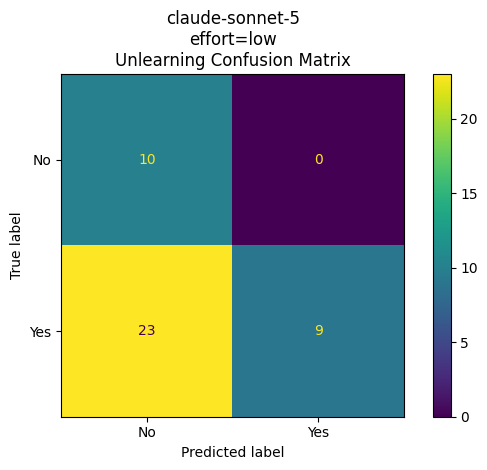

gemini gemini-3.1-flash-lite thinking_level=minimal
{'TN': 9, 'FP': 1, 'FN': 18, 'TP': 14}


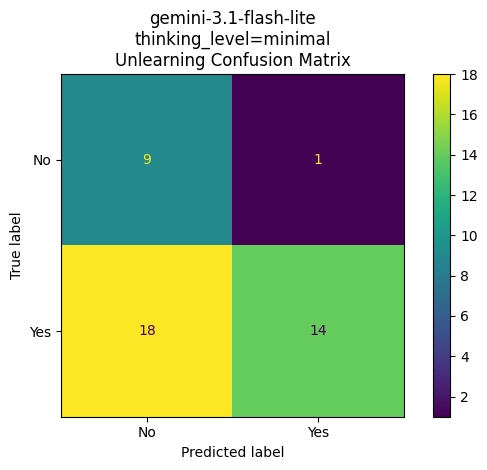

openai gpt-5.6-terra reasoning_effort=low
{'TN': 10, 'FP': 0, 'FN': 25, 'TP': 7}


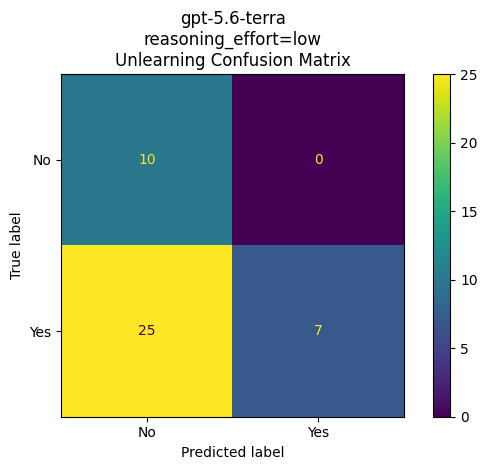

In [19]:
if results_df.empty:
    print('No results to plot yet.')
else:
    plot_df = results_df[results_df['status'].eq('ok')].copy()
    plot_df['y_true'] = plot_df['ground_truth_unlearning'].apply(normalize_yes_no)
    plot_df['y_pred'] = plot_df['pred_unlearning'].apply(normalize_yes_no)
    plot_df = plot_df.dropna(subset=['y_true', 'y_pred'])

    for group_values, group in plot_df.groupby(
        ['provider', 'model', 'model_effort'], dropna=False
    ):
        provider, model, effort = group_values
        matrix = confusion_matrix(group['y_true'], group['y_pred'], labels=['No', 'Yes'])
        tn, fp, fn, tp = matrix.ravel()
        print('=' * 70)
        print(provider, model, effort)
        print({'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)})
        display_plot = ConfusionMatrixDisplay(matrix, display_labels=['No', 'Yes'])
        display_plot.plot(values_format='d')
        plt.title(f'{model}\n{effort}\nUnlearning Confusion Matrix')
        plt.tight_layout()
        plt.show()

## 13. Save predictions, metrics, evidence diagnostics, and review rows

In [20]:
def excel_safe_frame(frame: pd.DataFrame) -> pd.DataFrame:
    safe = frame.copy()
    for column in safe.columns:
        safe[column] = safe[column].apply(
            lambda value: json.dumps(value, ensure_ascii=False, default=str)
            if isinstance(value, (list, dict, tuple, set))
            else value
        )
    return safe


OUTPUT_XLSX = OUTPUT_DIR / f'unlearning_results_{PROMPT_VERSION}.xlsx'
PREDICTIONS_CSV = OUTPUT_DIR / f'predictions_{PROMPT_VERSION}.csv'
METRICS_CSV = OUTPUT_DIR / f'metrics_{PROMPT_VERSION}.csv'
DOCUMENT_METRICS_CSV = OUTPUT_DIR / f'document_metrics_{PROMPT_VERSION}.csv'

if not results_df.empty:
    results_df.to_csv(PREDICTIONS_CSV, index=False)
    metrics_df.to_csv(METRICS_CSV, index=False)
    document_metrics_df.to_csv(DOCUMENT_METRICS_CSV, index=False)

with pd.ExcelWriter(OUTPUT_XLSX, engine='xlsxwriter') as writer:
    excel_safe_frame(test_df).to_excel(writer, sheet_name='Input_GPT_Test', index=False)
    excel_safe_frame(codebook_df).to_excel(writer, sheet_name='Codebook', index=False)
    excel_safe_frame(prompt_audit_df).to_excel(writer, sheet_name='Prompt_Audit', index=False)
    excel_safe_frame(estimate_df).to_excel(writer, sheet_name='Preflight_Estimates', index=False)

    if not results_df.empty:
        excel_safe_frame(results_df).to_excel(writer, sheet_name='Predictions_Long', index=False)
        excel_safe_frame(metrics_df).to_excel(writer, sheet_name='Metrics', index=False)
        excel_safe_frame(document_metrics_df).to_excel(writer, sheet_name='Metrics_By_Document', index=False)
        excel_safe_frame(disagreements_df).to_excel(writer, sheet_name='Disagreements', index=False)
        excel_safe_frame(evidence_diagnostics_df).to_excel(writer, sheet_name='Evidence_Diagnostics', index=False)

    workbook = writer.book
    wrap = workbook.add_format({'text_wrap': True, 'valign': 'top'})
    header = workbook.add_format({
        'bold': True, 'text_wrap': True, 'valign': 'top',
        'bg_color': '#1F4E78', 'font_color': '#FFFFFF',
    })

    for sheet_name, worksheet in writer.sheets.items():
        worksheet.freeze_panes(1, 0)
        worksheet.set_row(0, 30, header)
        worksheet.set_column(0, 0, 16, wrap)
        worksheet.set_column(1, 6, 35, wrap)
        worksheet.set_column(7, 50, 24, wrap)

print('Saved:', OUTPUT_XLSX)
if not results_df.empty:
    print('Saved:', PREDICTIONS_CSV)
    print('Saved:', METRICS_CSV)
    print('Saved:', DOCUMENT_METRICS_CSV)

Saved: outputs_unlearning_local_context_fixed/unlearning_results_v6_fixed_definitions_only_local_context_42.xlsx
Saved: outputs_unlearning_local_context_fixed/predictions_v6_fixed_definitions_only_local_context_42.csv
Saved: outputs_unlearning_local_context_fixed/metrics_v6_fixed_definitions_only_local_context_42.csv
Saved: outputs_unlearning_local_context_fixed/document_metrics_v6_fixed_definitions_only_local_context_42.csv


## What changed from the prior working notebook

- Added secure environment-variable setup for API keys through `.env`, Colab Secrets, or `getpass`.
- Uses only the supplied 42-row Local Context GPT Test and the current updated Codebook.
- Preserves the working provider wrappers and one-call-per-row execution pattern.
- Adds local context without allowing neighboring paragraphs to determine the target label by themselves.
- Adds evidence fields in the same single model call; there is no separate second-stage API workflow.
- Uses model/config-specific resume files so stale runs from another model are not mixed.
- Reports recall, specificity, balanced accuracy, macro-F1, MCC, document-level metrics, and exact disagreements.